In [71]:
!pip install shap xgboost scikit-learn pandas numpy matplotlib seaborn 

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Libraries loaded!")

Libraries loaded!


In [73]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")  # 7043 rows, 21 columns
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Dataset shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   


In [74]:
print(f"\n--- DATA TYPES ---")
print(df.dtypes)

print(f"\n--- MISSING VALUES ---")
print(df.isnull().sum())

print(f"\n--- CHURN DISTRIBUTION ---")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")


--- DATA TYPES ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- MISSING VALUES ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pa

In [75]:
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

TotalCharges dtype: object


In [76]:
print(f"\nNon-numeric TotalCharges:")
print(df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]['TotalCharges'].unique())


Non-numeric TotalCharges:
[' ']


In [77]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')
df['TotalCharges'].fillna(0,inplace = True)

print(f"\nTotalCharges dtype after fix: {df['TotalCharges'].dtype}")
print(f"Missing values after fix: {df['TotalCharges'].isnull().sum()}")


TotalCharges dtype after fix: float64
Missing values after fix: 0


In [78]:
df.drop('customerID', axis=1, inplace=True)
print(f"Shape after dropping customerID: {df.shape}")

Shape after dropping customerID: (7043, 20)


In [79]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"\nChurn column after conversion:")
print(df['Churn'].value_counts())


Churn column after conversion:
Churn
0    5174
1    1869
Name: count, dtype: int64


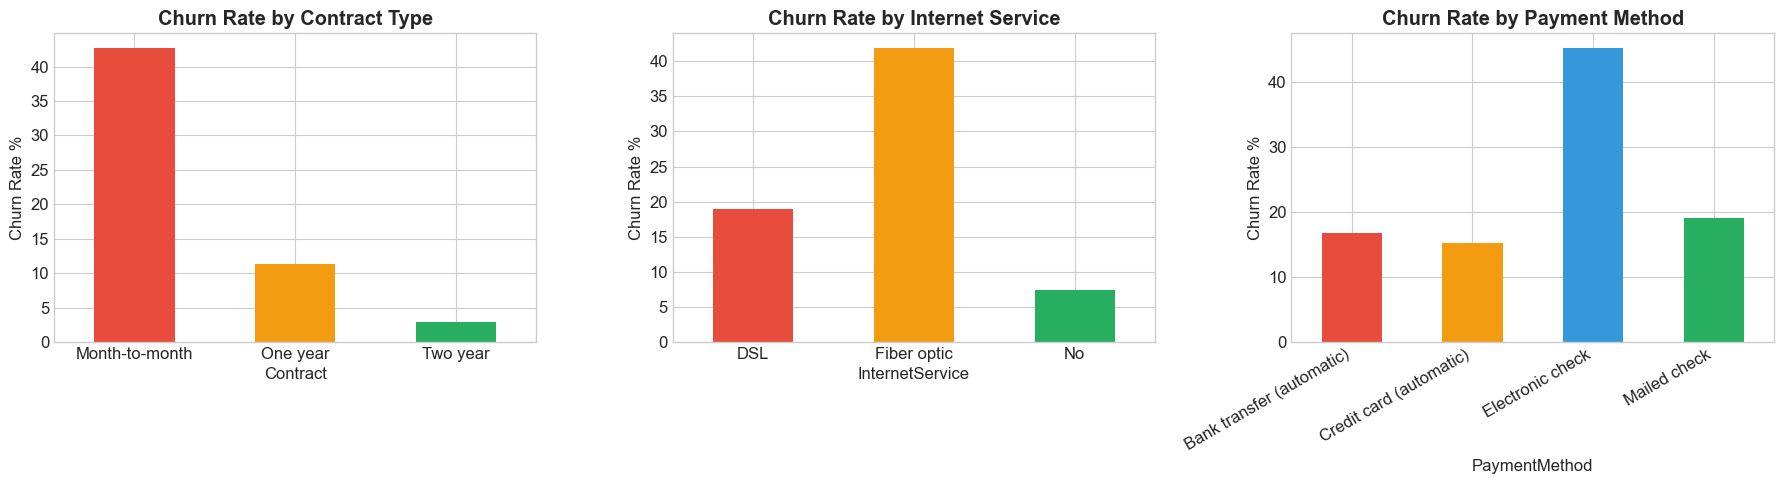

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_churn.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#f39c12', '#27ae60'])
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
internet_churn.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#f39c12', '#27ae60'])
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('Churn Rate %')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
payment_churn.plot(kind='bar', ax=axes[2], color=['#e74c3c', '#f39c12', '#3498db', '#27ae60'])
axes[2].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[2].set_ylabel('Churn Rate %')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('01_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

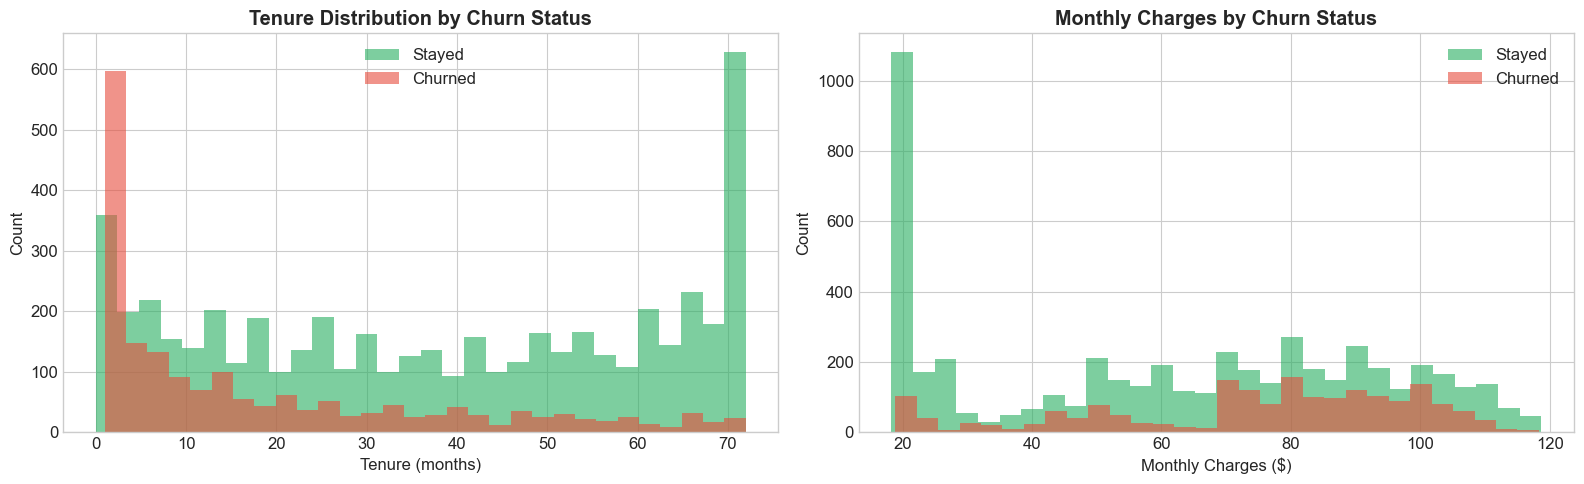

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6, label='Stayed', color='#27ae60')
axes[0].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[0].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30, alpha=0.6, label='Stayed', color='#27ae60')
axes[1].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[1].set_title('Monthly Charges by Churn Status', fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('02_tenure_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [82]:
numeric_cols = df.select_dtypes(include = [np.number]).columns
print(numeric_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


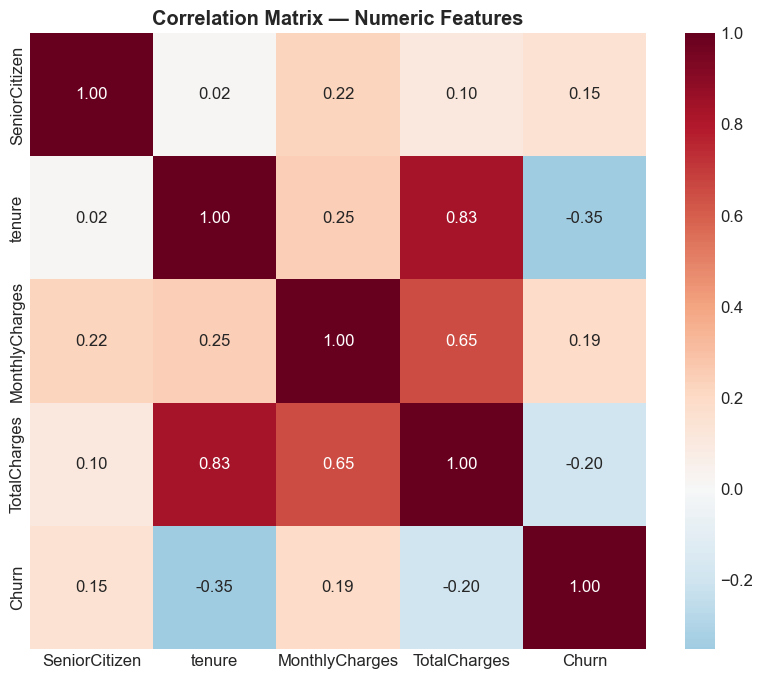

In [83]:
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [84]:
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns ({len(cat_cols)}):")
print(list(cat_cols))

Categorical columns (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [85]:
binary_cols = []
multi_cols = []
for col in cat_cols:
    if df[col].nunique() == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"\nBinary columns: {binary_cols}")
print(f"Multi-category columns: {multi_cols}")


Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [86]:
# Label Encoding
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [87]:
# One Hot Encoding
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"\nShape after encoding: {df.shape}")
print(f"All columns are now numeric: {df.dtypes.unique()}")


Shape after encoding: (7043, 31)
All columns are now numeric: [dtype('int64') dtype('float64') dtype('bool')]


In [89]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")



Features (X): (7043, 30)
Target (y): (7043,)
Churn rate: 26.5%


In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining: {X_train.shape[0]} customers")
print(f"Testing:  {X_test.shape[0]} customers")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")


Training: 5634 customers
Testing:  1409 customers
Train churn rate: 26.5%
Test churn rate:  26.5%


In [93]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                               columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), 
                              columns=X_test.columns, index=X_test.index)

In [94]:
X_train['tenure'].describe()

count    5634.000000
mean       32.485091
std        24.568744
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [95]:
X_train_scaled['tenure'].describe()

count    5.634000e+03
mean    -1.008935e-17
std      1.000089e+00
min     -1.322329e+00
25%     -9.559779e-01
50%     -1.418632e-01
75%      9.164859e-01
max      1.608483e+00
Name: tenure, dtype: float64

In [97]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained!")

Logistic Regression trained!


In [98]:
lr_pred = lr_model.predict(X_test_scaled)           # 0 or 1
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of churn

print(f"\nSample predictions (first 10):")
for i in range(10):
    actual = "Churned" if y_test.iloc[i] == 1 else "Stayed"
    predicted = "Churned" if lr_pred[i] == 1 else "Stayed"
    print(f"  Customer {i+1}: Actual={actual}, Predicted={predicted}, Probability={lr_prob[i]:.2f}")


Sample predictions (first 10):
  Customer 1: Actual=Stayed, Predicted=Stayed, Probability=0.04
  Customer 2: Actual=Stayed, Predicted=Churned, Probability=0.68
  Customer 3: Actual=Stayed, Predicted=Stayed, Probability=0.06
  Customer 4: Actual=Stayed, Predicted=Stayed, Probability=0.41
  Customer 5: Actual=Stayed, Predicted=Stayed, Probability=0.02
  Customer 6: Actual=Stayed, Predicted=Churned, Probability=0.60
  Customer 7: Actual=Stayed, Predicted=Stayed, Probability=0.45
  Customer 8: Actual=Stayed, Predicted=Stayed, Probability=0.13
  Customer 9: Actual=Stayed, Predicted=Stayed, Probability=0.00
  Customer 10: Actual=Churned, Predicted=Stayed, Probability=0.39


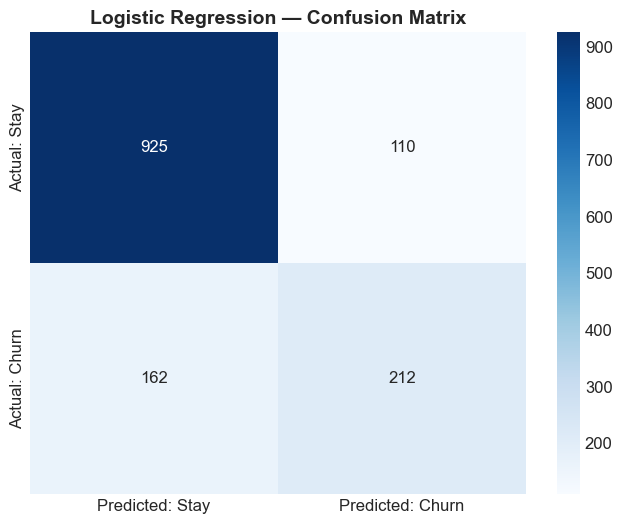

In [100]:
cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
plt.savefig('04_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [101]:
print("\n" + "=" * 60)
print("   LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, lr_pred, target_names=['Stay', 'Churn']))

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print(f"Accuracy:  {lr_accuracy*100:.1f}%")
print(f"Precision: {lr_precision*100:.1f}%")
print(f"Recall:    {lr_recall*100:.1f}%")
print(f"F1-Score:  {lr_f1*100:.1f}%")
print(f"AUC-ROC:   {lr_auc:.3f}")


   LOGISTIC REGRESSION — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Accuracy:  80.7%
Precision: 65.8%
Recall:    56.7%
F1-Score:  60.9%
AUC-ROC:   0.842


In [103]:
# RANDOM FOREST 
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    min_samples_leaf = 5,
    random_state = 42,
    class_weight = 'balanced',
    n_jobs = 1
)

In [104]:
rf_model.fit(X_train,y_train)
print('Random forest trained!(200 trees)')

Random forest trained!(200 trees)


In [107]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("\n" + "=" * 60)
print("   RANDOM FOREST — CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=['Stay', 'Churn']))

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy:  {rf_accuracy*100:.1f}%")
print(f"Precision: {rf_precision*100:.1f}%")
print(f"Recall:    {rf_recall*100:.1f}%")
print(f"F1-Score:  {rf_f1*100:.1f}%")
print(f"AUC-ROC:   {rf_auc:.3f}")


   RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Stay       0.90      0.77      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

Accuracy:  76.9%
Precision: 54.6%
Recall:    77.5%
F1-Score:  64.1%
AUC-ROC:   0.844


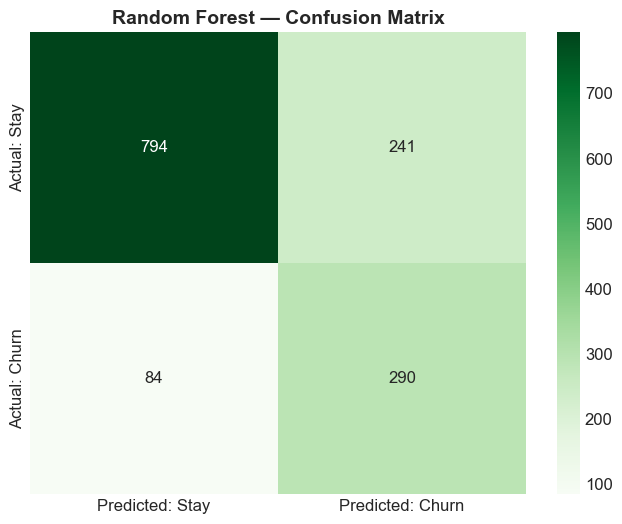

In [108]:
cm_rf = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
ax.set_title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
plt.savefig('05_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

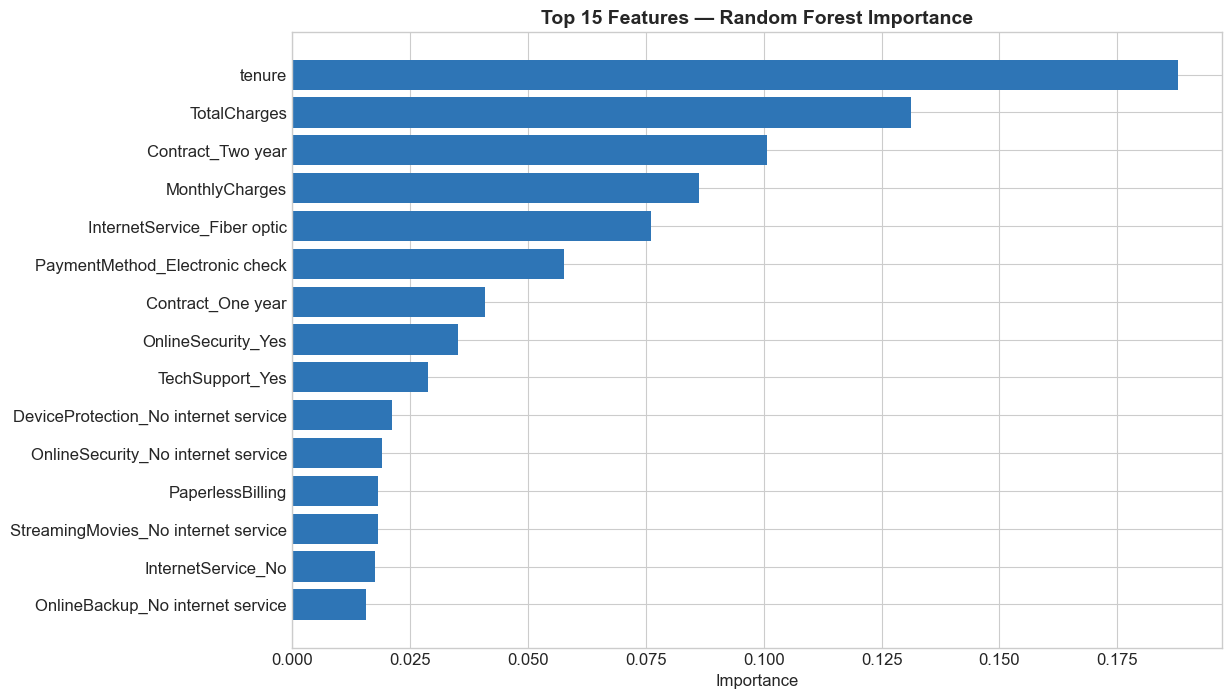

Top 10 churn predictors:
  1. tenure                              0.1878
  2. TotalCharges                        0.1312
  3. Contract_Two year                   0.1007
  4. MonthlyCharges                      0.0862
  5. InternetService_Fiber optic         0.0761
  6. PaymentMethod_Electronic check      0.0578
  7. Contract_One year                   0.0409
  8. OnlineSecurity_Yes                  0.0351
  9. TechSupport_Yes                     0.0288
  10. DeviceProtection_No internet service 0.0212


In [116]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_15 = feature_importance.head(15)
ax.barh(range(len(top_15)), top_15['importance'], color='#2e75b6')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'])
ax.invert_yaxis()  # Highest importance at top
ax.set_title('Top 15 Features — Random Forest Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.savefig('06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 churn predictors:")
for i, (_, row) in enumerate(feature_importance.head(10).iterrows()):
    print(f"  {i+1}. {row['feature']:<35} {row['importance']:.4f}")

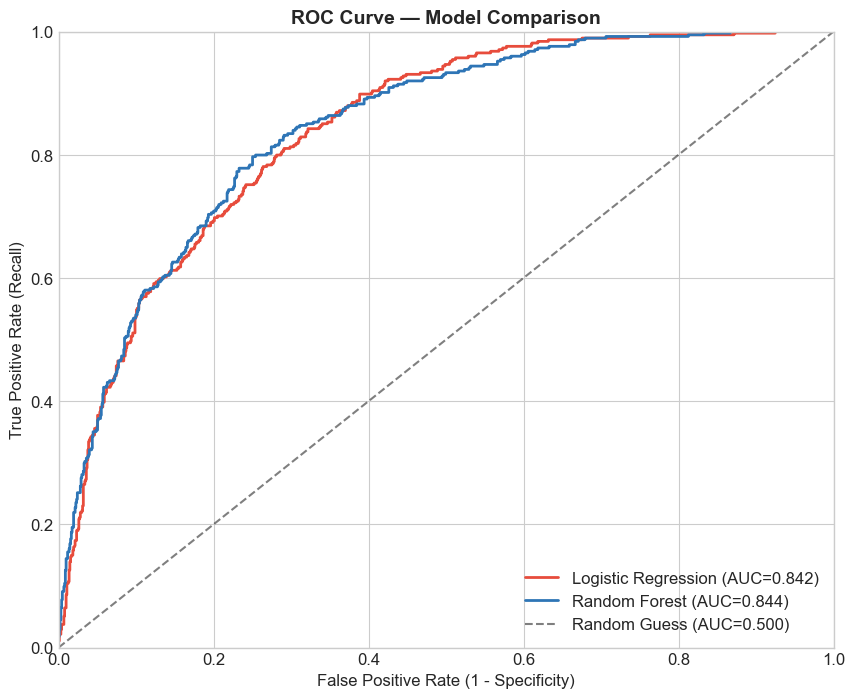

In [119]:
fig, ax = plt.subplots(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', 
        color='#e74c3c', linewidth=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', 
        color='#2e75b6', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess (AUC=0.500)')

ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.savefig('07_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [126]:
print("\n" + "=" * 70)
print("              📊 MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Metric':<20} {'Logistic Regression':>20} {'Random Forest':>20}")
print("-" * 70)
print(f"{'Accuracy':<20} {lr_accuracy*100:>19.1f}% {rf_accuracy*100:>19.1f}%")
print(f"{'Precision':<20} {lr_precision*100:>19.1f}% {rf_precision*100:>19.1f}%")
print(f"{'Recall':<20} {lr_recall*100:>19.1f}% {rf_recall*100:>19.1f}%")
print(f"{'F1-Score':<20} {lr_f1*100:>19.1f}% {rf_f1*100:>19.1f}%")
print(f"{'AUC-ROC':<20} {lr_auc:>20.3f} {rf_auc:>20.3f}")
print("=" * 70)


              📊 MODEL COMPARISON SUMMARY
Metric                Logistic Regression        Random Forest
----------------------------------------------------------------------
Accuracy                            80.7%                76.9%
Precision                           65.8%                54.6%
Recall                              56.7%                77.5%
F1-Score                            60.9%                64.1%
AUC-ROC                             0.842                0.844


SHAP values calculated!
Churn SHAP shape: (1409, 30)


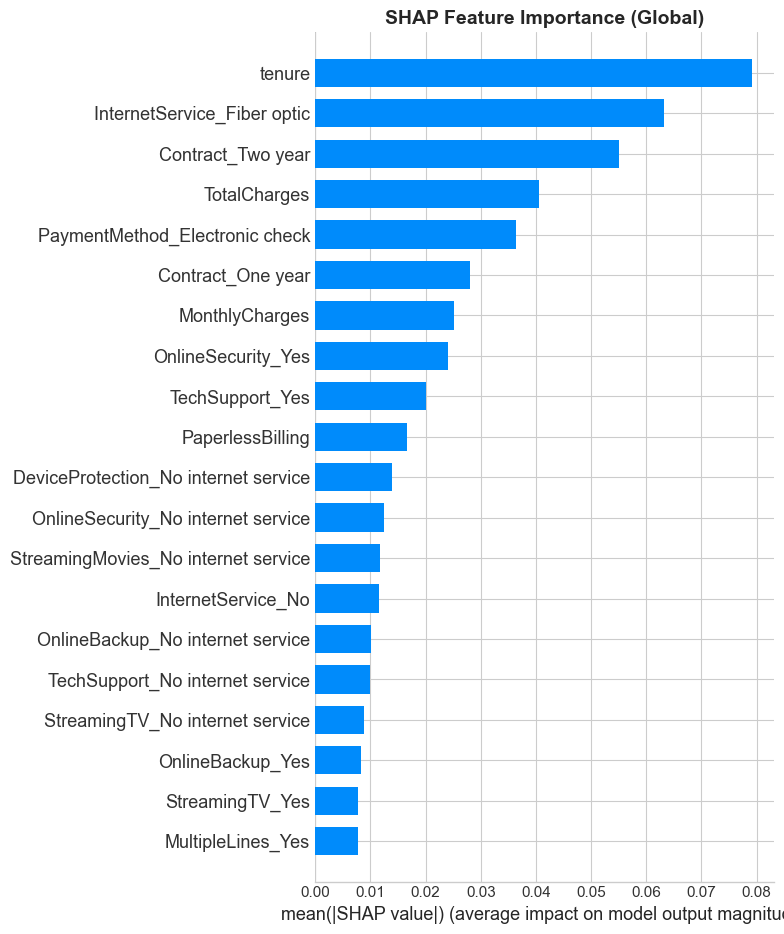

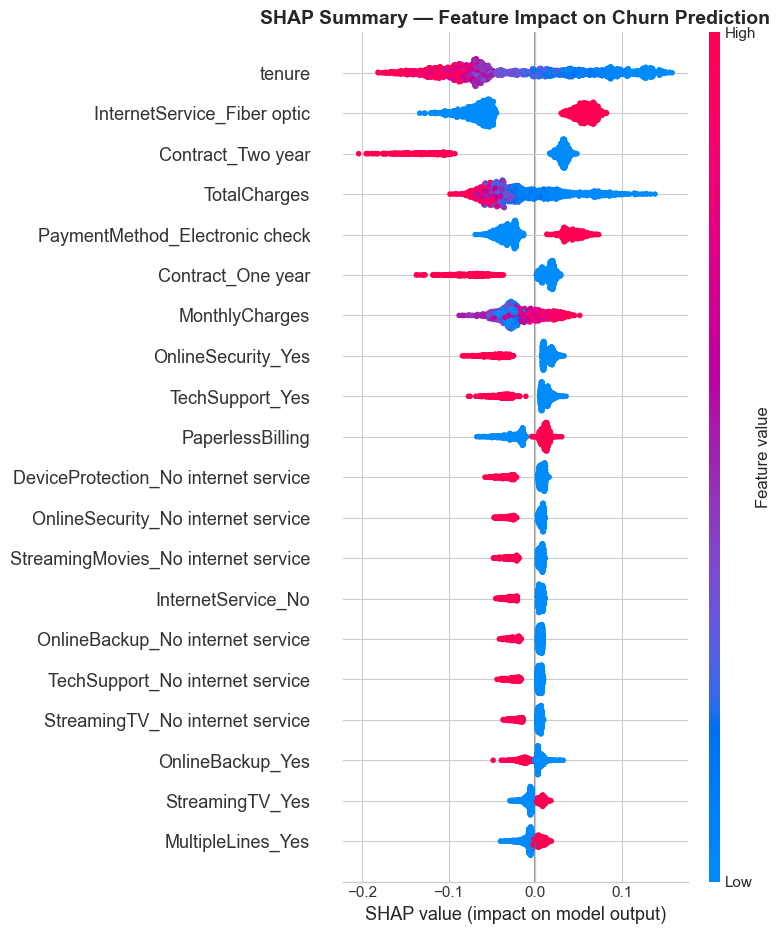

In [130]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")

if isinstance(shap_values, list):
    shap_churn = shap_values[1]          # old SHAP version
    base_value = explainer.expected_value[1]
else:
    shap_churn = shap_values[:, :, 1]    # new SHAP version
    base_value = explainer.expected_value[1]


print(f"Churn SHAP shape: {shap_churn.shape}")


fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_churn, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
shap.summary_plot(shap_churn, X_test, show=False)
plt.title('SHAP Summary — Feature Impact on Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


--- EXPLAINING CUSTOMER #1 ---
Churn probability: 0.85
Actual outcome: Stayed

Key features:
  Tenure: 8 months
  Monthly charges: $100.15
  Total charges: $908.55


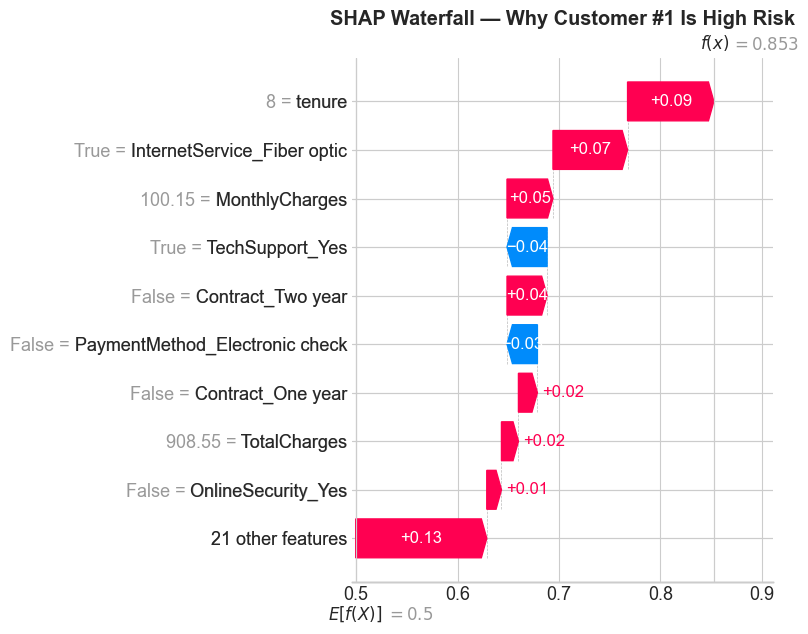

In [131]:
high_risk_idx = np.where(rf_prob > 0.8)[0]
if len(high_risk_idx) > 0:
    customer_idx = high_risk_idx[0]
else:
    customer_idx = np.argmax(rf_prob)

print(f"\n--- EXPLAINING CUSTOMER #{customer_idx} ---")
print(f"Churn probability: {rf_prob[customer_idx]:.2f}")
print(f"Actual outcome: {'Churned' if y_test.iloc[customer_idx]==1 else 'Stayed'}")
print(f"\nKey features:")
customer_data = X_test.iloc[customer_idx]
print(f"  Tenure: {customer_data['tenure']} months")
print(f"  Monthly charges: ${customer_data['MonthlyCharges']:.2f}")
print(f"  Total charges: ${customer_data['TotalCharges']:.2f}")

fig, ax = plt.subplots(figsize=(12, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_churn[customer_idx],
    base_values=base_value,
    data=X_test.iloc[customer_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.title(f'SHAP Waterfall — Why Customer #{customer_idx} Is High Risk', fontweight='bold')
plt.tight_layout()
plt.savefig('10_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


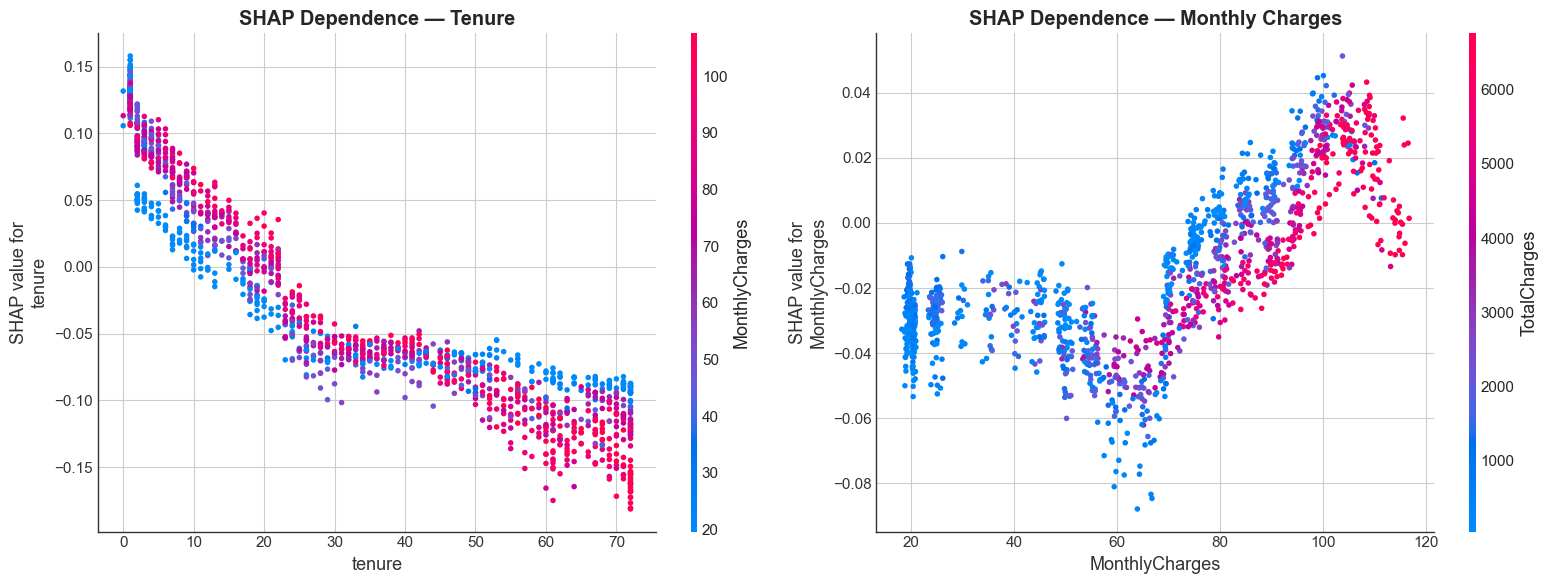

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap.dependence_plot('tenure', shap_churn, X_test, ax=axes[0], show=False)
axes[0].set_title('SHAP Dependence — Tenure', fontweight='bold')

shap.dependence_plot('MonthlyCharges', shap_churn, X_test, ax=axes[1], show=False)
axes[1].set_title('SHAP Dependence — Monthly Charges', fontweight='bold')

plt.tight_layout()
plt.savefig('11_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [133]:
print("\n" + "=" * 70)
print("     📋 EXECUTIVE SUMMARY — CHURN PREDICTION MODEL")
print("=" * 70)
print(f"""
DATASET:  Telco Customer Churn (7,043 customers, 21 features)
MODELS:   Logistic Regression, Random Forest
BEST:     {'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'} (AUC: {max(rf_auc, lr_auc):.3f})

KEY CHURN DRIVERS (from SHAP analysis):
  1. Low tenure — New customers are highest risk
  2. Month-to-month contract — No commitment = easy to leave
  3. High monthly charges — Price sensitivity
  4. Fiber optic internet — Possible service quality issues
  5. No tech support/online security — Poor support experience
  6. Electronic check payment — Less engaged (not auto-pay)

BUSINESS RECOMMENDATIONS:
  1. EARLY INTERVENTION: Flag customers in first 6 months for proactive
     outreach. Offer loyalty discounts or personalized onboarding.
  
  2. CONTRACT INCENTIVES: Offer discounts for annual/two-year contracts.
     Month-to-month customers have 5-10x higher churn rate.
  
  3. PRICING REVIEW: Customers paying >$80/month churn significantly more.
     Consider value-add bundles instead of price increases.
  
  4. FIBER OPTIC QUALITY: Investigate why fiber customers churn more
     than DSL. Possible network quality or billing issues.
  
  5. SUPPORT BUNDLING: Customers with tech support and online security
     churn less. Bundle these with high-risk accounts.
  
  6. PAYMENT METHOD: Encourage auto-pay (bank transfer/credit card).
     Electronic check users show highest churn — possibly friction-related.

MODEL DEPLOYMENT APPROACH:
  - Score all active customers monthly
  - Flag top 10% highest churn probability for retention team
  - Track intervention success rate (A/B test: contacted vs not contacted)
  - Retrain model quarterly with fresh data
""")
print("=" * 70)


     📋 EXECUTIVE SUMMARY — CHURN PREDICTION MODEL

DATASET:  Telco Customer Churn (7,043 customers, 21 features)
MODELS:   Logistic Regression, Random Forest
BEST:     Random Forest (AUC: 0.844)

KEY CHURN DRIVERS (from SHAP analysis):
  1. Low tenure — New customers are highest risk
  2. Month-to-month contract — No commitment = easy to leave
  3. High monthly charges — Price sensitivity
  4. Fiber optic internet — Possible service quality issues
  5. No tech support/online security — Poor support experience
  6. Electronic check payment — Less engaged (not auto-pay)

BUSINESS RECOMMENDATIONS:
  1. EARLY INTERVENTION: Flag customers in first 6 months for proactive
     outreach. Offer loyalty discounts or personalized onboarding.

  2. CONTRACT INCENTIVES: Offer discounts for annual/two-year contracts.
     Month-to-month customers have 5-10x higher churn rate.

  3. PRICING REVIEW: Customers paying >$80/month churn significantly more.
     Consider value-add bundles instead of price